# FinOKF vs Naive

Two views of successful agent runs:

1. **Per question:** mean token usage and latency across matched model runs.
2. **Aggregated by model:** mean token usage and latency across matched questions.

Only question/model combinations where both FinOKF and Naive succeeded are compared.

## Setup

The notebook reads `question_metrics.csv` from the `paper` folder. It uses only local project data and does not make network requests.

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "#F7F8FA",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#D9DEE7",
    "axes.titleweight": "bold",
    "axes.labelcolor": "#353A44",
    "font.family": "DejaVu Sans",
    "grid.color": "#E9ECF2",
    "grid.linewidth": 0.8,
})

In [56]:
candidates = [Path("question_metrics.csv"), Path("paper/question_metrics.csv")]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Run this notebook from the repository root or paper folder.")

raw = pd.read_csv(data_path)
required = {"question_id", "agent", "total_tokens", "elapsed_ms", "provider", "model", "status"}
missing = required.difference(raw.columns)
if missing:
    raise ValueError(f"Missing CSV columns: {sorted(missing)}")

data = raw.loc[raw["status"].eq("ok")].copy()
data["question_id"] = data["question_id"].astype(str)
data["agent"] = data["agent"].map({"finokf": "FinOKF", "naive": "Naive"})
data["elapsed_seconds"] = data["elapsed_ms"] / 1000.0
data["model_key"] = data["provider"] + "/" + data["model"]

pair_counts = data.groupby(["question_id", "model_key"])["agent"].nunique()
complete_pairs = pair_counts[pair_counts.eq(2)].index
data = data.set_index(["question_id", "model_key"]).loc[complete_pairs].reset_index()
ASSET_ROOT = data_path.parent / "assets"
if not (ASSET_ROOT / "anthropic.png").exists():
    raise FileNotFoundError(f"Missing provider logo assets in {ASSET_ROOT}")
print(f"Using {len(data)} rows across {len(complete_pairs)} matched agent pairs.")

Using 32 rows across 16 matched agent pairs.


In [ ]:
QUESTION_ORDER = ["1.1", "1.2", "1.3", "2.1", "2.2", "2.3", "2.4"]
AGENT_ORDER = ["Naive", "FinOKF"]
AGENT_COLORS = {"Naive": "#D64545", "FinOKF": "#138A7A"}
MODEL_ORDER = [
    "anthropic/claude-sonnet-5",
    "openai/gpt-5.5",
    "ollama/llama3.2:3b",
]
MODEL_STYLE = {
    "anthropic/claude-sonnet-5": {"label": "Claude Sonnet 5", "color": "#E8752B", "asset": "anthropic.png"},
    "openai/gpt-5.5": {"label": "GPT-5.5", "color": "#1479FF", "asset": "openai.png"},
    "ollama/llama3.2:3b": {"label": "Llama 3.2 3B", "color": "#111111", "asset": "ollama.png"},
}


def compact_number(value):
    return f"{value / 1000:.1f}k" if value >= 1000 else f"{value:.0f}"

In [ ]:
def grouped_bars(ax, frame, category, value, order, ylabel, log_scale=False):
    x = np.arange(len(order))
    width = 0.34
    for index, agent in enumerate(AGENT_ORDER):
        values = (
            frame.loc[frame["agent"].eq(agent)]
            .set_index(category)[value]
            .reindex(order)
        )
        positions = x + (index - 0.5) * width
        bars = ax.bar(
            positions, values, width,
            color=AGENT_COLORS[agent], label=agent,
            edgecolor="white", linewidth=1.2, zorder=3,
        )
        if not log_scale:
            labels = [compact_number(v) if value == "total_tokens" else f"{v:.1f}s" for v in values]
            ax.bar_label(bars, labels=labels, padding=3, fontsize=9, color="#4B5260")
    ax.set_xticks(x, order)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=False)
    if log_scale:
        ax.set_yscale("log")


def add_model_logo_ticks(ax, model_order):
    ax.set_xticks(np.arange(len(model_order)))
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)
    for x, model_key in enumerate(model_order):
        style = MODEL_STYLE[model_key]
        logo = plt.imread(ASSET_ROOT / style["asset"])
        # Normalize different source resolutions to the same visible logo size.
        logo_pixels = max(logo.shape[:2])
        logo_box = OffsetImage(logo, zoom=30 / logo_pixels)
        logo_artist = AnnotationBbox(
            logo_box, (x, -0.13), xycoords=ax.get_xaxis_transform(),
            frameon=True, box_alignment=(0.5, 0.5), clip_on=False,
            bboxprops={"boxstyle": "circle,pad=0.38", "facecolor": "white", "edgecolor": style["color"], "linewidth": 2.0},
        )
        ax.add_artist(logo_artist)
        ax.text(
            x, -0.25, style["label"], color="#252A34", weight="bold", fontsize=10,
            ha="center", va="top", transform=ax.get_xaxis_transform(), clip_on=False,
        )

## Figure 1 — Per-question comparison

Each bar is the mean across available matched model runs for that question. The token panel uses a logarithmic scale so both agents remain readable despite their large usage difference.

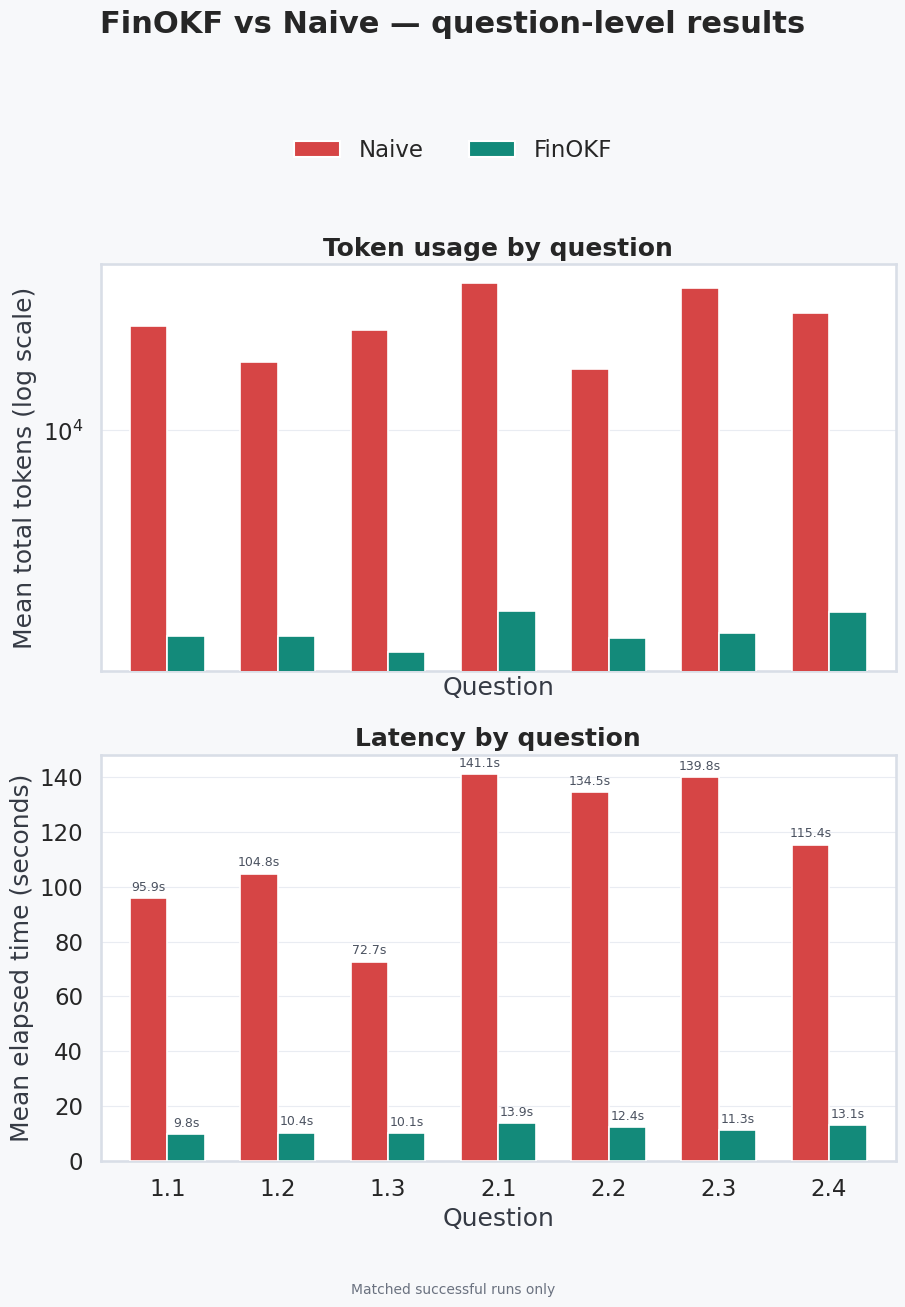

In [ ]:
question_summary = (
    data.groupby(["question_id", "agent"], as_index=False)
    .agg(total_tokens=("total_tokens", "mean"), elapsed_seconds=("elapsed_seconds", "mean"))
)

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
grouped_bars(
    axes[0], question_summary, "question_id", "total_tokens", QUESTION_ORDER,
    "Mean total tokens (log scale)", log_scale=True,
)
grouped_bars(
    axes[1], question_summary, "question_id", "elapsed_seconds", QUESTION_ORDER,
    "Mean elapsed time (seconds)",
)
axes[0].set_title("Token usage by question")
axes[1].set_title("Latency by question")
for ax in axes:
    ax.set_xlabel("Question")
    ax.margins(x=0.04)

handles = [Patch(facecolor=AGENT_COLORS[name], label=name) for name in AGENT_ORDER]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.99))
fig.suptitle("FinOKF vs Naive — question-level results", fontsize=22, weight="bold", y=1.08)
fig.text(0.5, 0.01, "Matched successful runs only", ha="center", color="#6B7280", fontsize=10)
plt.tight_layout(rect=(0.03, 0.04, 0.97, 0.96))
fig.savefig(ASSET_ROOT / "question_results_vertical.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 2 — Aggregated model comparison

Each bar is the mean across available matched questions for that model. Provider-colored logo badges identify the model labels on the x-axis.

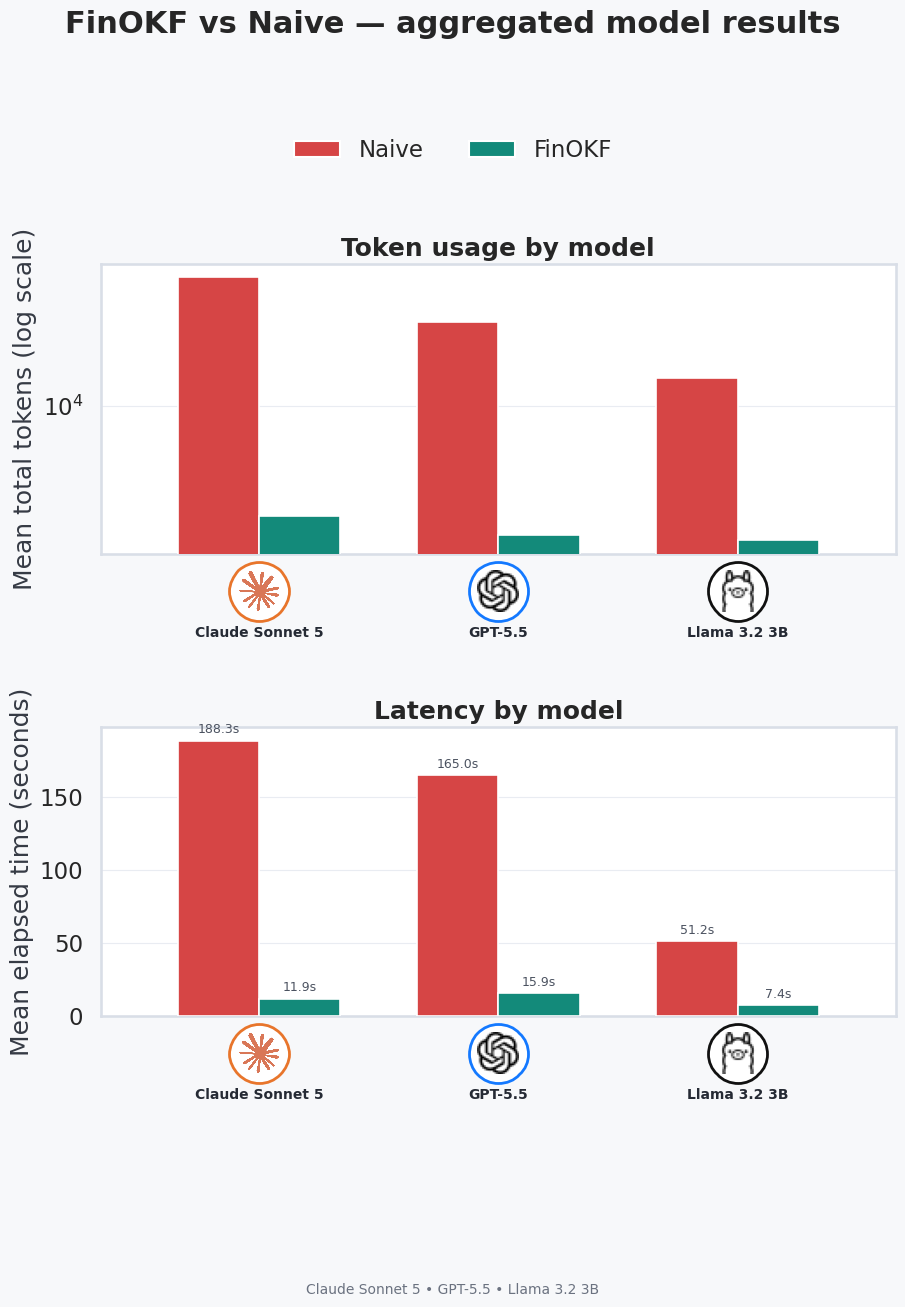

In [ ]:
model_summary = (
    data.groupby(["model_key", "agent"], as_index=False)
    .agg(total_tokens=("total_tokens", "mean"), elapsed_seconds=("elapsed_seconds", "mean"))
)

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
grouped_bars(
    axes[0], model_summary, "model_key", "total_tokens", MODEL_ORDER,
    "Mean total tokens (log scale)", log_scale=True,
)
grouped_bars(
    axes[1], model_summary, "model_key", "elapsed_seconds", MODEL_ORDER,
    "Mean elapsed time (seconds)",
)
axes[0].set_title("Token usage by model")
axes[1].set_title("Latency by model")
for ax in axes:
    ax.set_xlabel("")
    add_model_logo_ticks(ax, MODEL_ORDER)
    ax.margins(x=0.12)

fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.99))
fig.suptitle("FinOKF vs Naive — aggregated model results", fontsize=22, weight="bold", y=1.08)
fig.text(0.5, 0.01, "Claude Sonnet 5 • GPT-5.5 • Llama 3.2 3B", ha="center", color="#6B7280", fontsize=10)
plt.tight_layout(rect=(0.03, 0.12, 0.97, 0.96))
fig.savefig(ASSET_ROOT / "model_results_vertical.png", dpi=300, bbox_inches="tight")
plt.show()

## Source and interpretation

Source: `paper/question_metrics.csv`, generated from the project’s saved agent runs. Run all cells before interpreting the figures. Differences may reflect model behavior, prompt size, retrieval work, caching, and provider latency—not only agent architecture.